# Helical acquisition and reconstruction testing

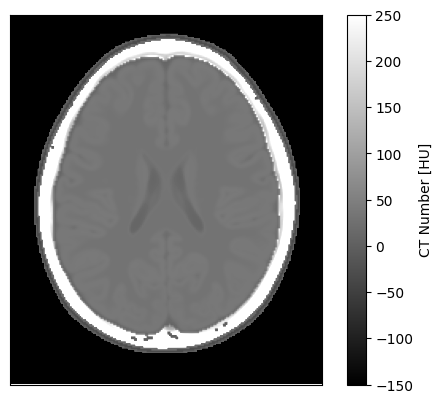

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from insilicoICH.ground_truth_definition.phantoms import NIHPD_Head

from utils import ctshow

nihpd_dir = Path('../phantom_dir/NIHPD_Head_Phantom')
nihpd = NIHPD_Head(nihpd_dir, age=11.5)

vol = nihpd.get_CT_number_phantom()
im = ctshow(vol[len(vol)//2])
plt.colorbar(im, label='CT Number [HU]')

In [2]:
from insilicoICH.image_acquisition import Scanner

nihpd.patient_name = 'helical_test'
scanner = Scanner(nihpd)
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing helical_test/phantoms/0/0_ncat_ad


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

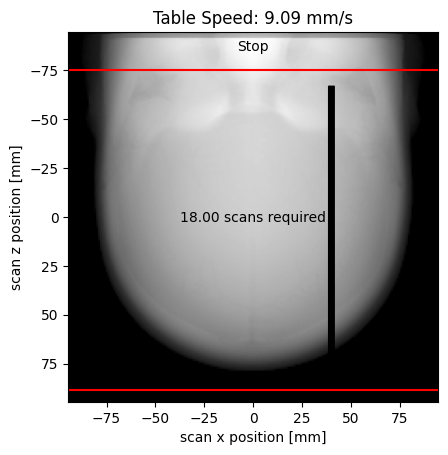

In [3]:
acquisition_technique = dict(
    startZ=-75,
    endZ=80,
    pitch=1)
scanner.scout_view(**acquisition_technique)

In [4]:
import gecatsim as xc
ct = xc.CatSim("../src/insilicoICH/defaults/helical_cfg/Phantom_Sample_Analytic",
               "../src/insilicoICH/defaults/helical_cfg/Protocol_Sample_Helical",
               "../src/insilicoICH/defaults/helical_cfg/Scanner_Sample_generic",
               "../src/insilicoICH/defaults/helical_cfg/Physics_Sample",
               "../src/insilicoICH/defaults/helical_cfg/Recon_Sample_Helical",
        )  # initialization

ct.phantom.filename = scanner.xcist.cfg.phantom.filename

ct.cfg.protocol.startZ = -4

# ct.cfg.protocol.tableSpeed = 8

M = ct.cfg.scanner.sdd/ct.cfg.scanner.sid
nominal_aperature = ct.cfg.scanner.detectorRowSize*ct.cfg.scanner.detectorRowCount/M # nominal_aperature == s
pitch = ct.cfg.protocol.tableSpeed*ct.cfg.protocol.rotationTime/nominal_aperature

ct.cfg.protocol.startViewId = 0
ct.cfg.protocol.stopViewId = ct.cfg.protocol.startViewId+ct.cfg.protocol.viewCount-1
ct.resultsName = "test_Helical"

rotations = ct.cfg.protocol.viewCount/ct.cfg.protocol.viewsPerRotation
scan_duration = ct.cfg.protocol.rotationTime*rotations # s/rotation*rotations
scan_length = ct.cfg.protocol.tableSpeed*scan_duration
rotations, scan_duration, scan_length, pitch

print(f'pitch: {pitch}, scan_length: {scan_length}')
ct.run_all()

pitch: 0.29192708333333334, scan_length: 23.895
Airscan
Offset scan
Phantom scan


  0%|          | 0/9000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.


in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 9000/9000 [34:59<00:00,  4.29it/s]


Prep view
Applying LSC...done.

Simulation is done.


slice thickness: 1, sliceCount: 23
* Loading the projection data...
* Rebinning the projection...
* Applying the filter...


* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/23...
   recon slice 1/23...
   recon slice 2/23...
   recon slice 3/23...
   recon slice 4/23...
   recon slice 5/23...
   recon slice 6/23...
   recon slice 7/23...
   recon slice 8/23...
   recon slice 9/23...
   recon slice 10/23...
   recon slice 11/23...
   recon slice 12/23...
   recon slice 13/23...
   recon slice 14/23...
   recon slice 15/23...
   recon slice 16/23...
   recon slice 17/23...
   recon slice 18/23...
   recon slice 19/23...
   recon slice 20/23...
   recon slice 21/23...
   recon slice 22/23...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


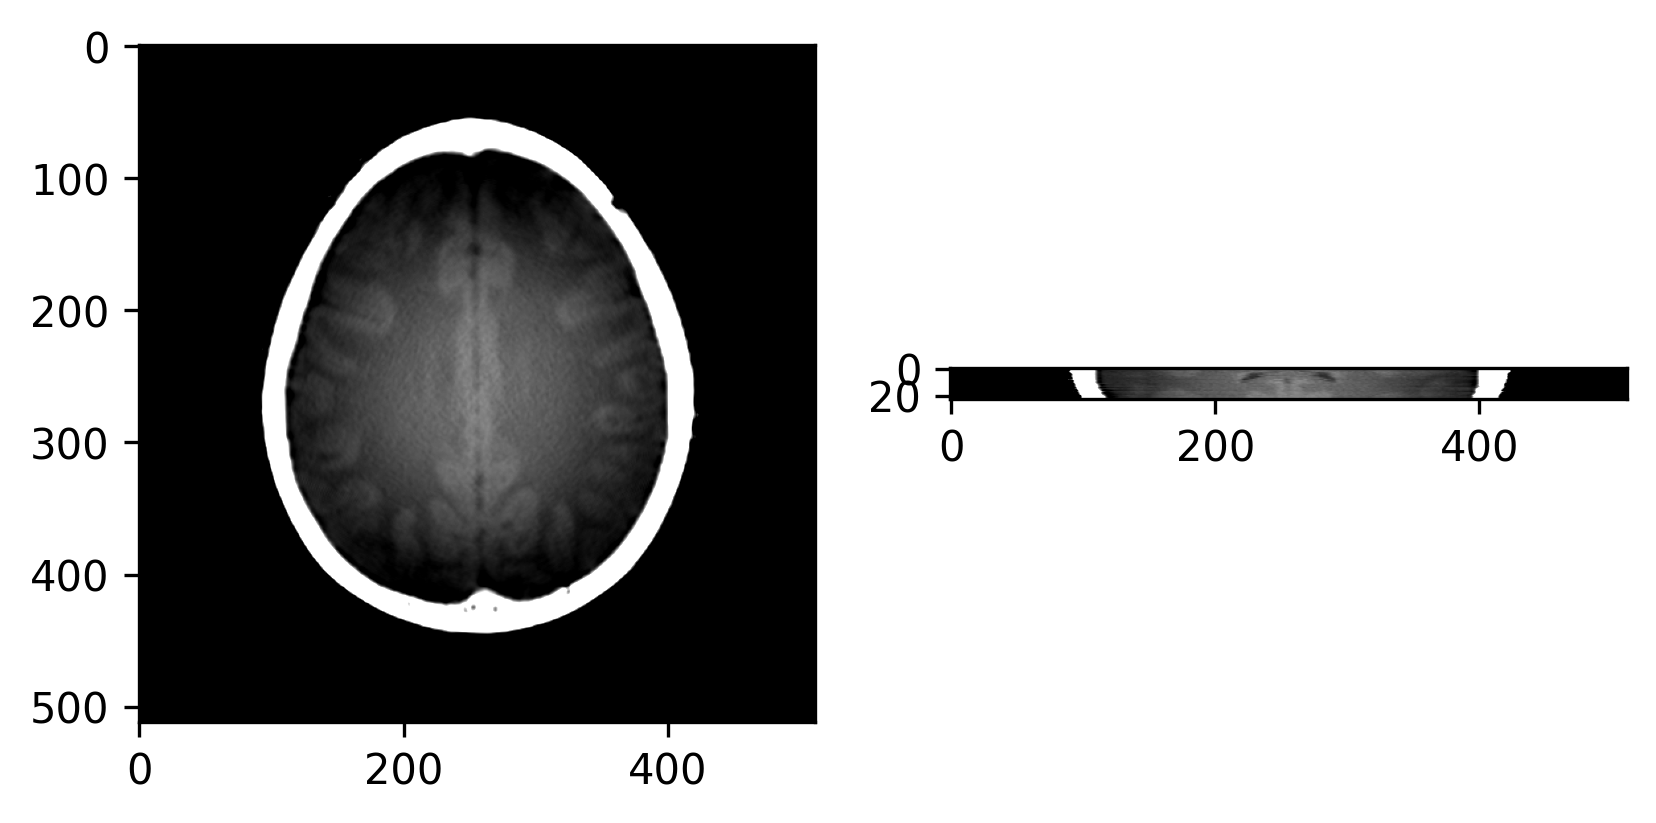

In [5]:
from gecatsim.reconstruction.pyfiles import recon

if ct.physics.monochromatic>0:
        ct.recon.mu = xc.GetMu('water', ct.physics.monochromatic)[0]/10

cfg = ct.get_current_cfg()

sliceThickness = 1
cfg.recon.sliceThickness = sliceThickness #0.568
sliceCount = int(scan_length / cfg.recon.sliceThickness)
cfg.recon.sliceCount = sliceCount
print(f'slice thickness: {cfg.recon.sliceThickness}, sliceCount: {cfg.recon.sliceCount}')

cfg.do_Recon = 1
cfg.waitForKeypress = 0
cfg.recon.printReconParameters = False
vol = recon.recon_direct(cfg).transpose(2, 0, 1)

ww, wl = 80, 40
disp = dict(cmap='gray', vmin=wl-ww/2, vmax=wl+ww/2)
f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(vol[len(vol)//2], **disp)
axs[1].imshow(vol[:, 256], **disp)

In [6]:
from utils import scrollview
scrollview(vol, 'brain')

interactive(children=(IntSlider(value=11, description='idx', max=22), Output()), _dom_classes=('widget-interac…

Below assigns pitch to set table speed

In [ ]:
import pandas as pd
import gecatsim as xc
from gecatsim.reconstruction.pyfiles import recon
import numpy as np

##--------- Initialize 
ct = xc.CatSim("../src/insilicoICH/defaults/helical_cfg/Phantom_Sample_Analytic",
               "../src/insilicoICH/defaults/helical_cfg/Protocol_Sample_Helical",
               "../src/insilicoICH/defaults/helical_cfg/Scanner_Sample_generic",
               "../src/insilicoICH/defaults/helical_cfg/Physics_Sample",
               "../src/insilicoICH/defaults/helical_cfg/Recon_Sample_Helical",
        )  # initialization

##--------- Make changes to parameters (optional)
# ct.phantom.filename = 'water20.ppm'
#ct.phantom.filename = 'CTDI_16cm_WaterAirPEBoneChambers.ppm'
ct.phantom.filename = scanner.xcist.cfg.phantom.filename
# rotations =
# scan_length = 50 # mm
desired_scan_length = 70 # mm
pitch = 1


M = ct.cfg.scanner.sdd/ct.cfg.scanner.sid
sliceThickness = ct.cfg.scanner.detectorRowSize/M
nominal_aperature = sliceThickness*ct.cfg.scanner.detectorRowCount # nominal_aperature == s

# ct.cfg.protocol.tableSpeed = 10

# table_travel_per_rotation = pitch*nominal_aperature # table_travel_per_rotation == d == v*t
# h = vt/s = d/s
# pitch = ct.cfg.protocol.tableSpeed*ct.cfg.protocol.rotationTime/nominal_aperature
ct.cfg.protocol.tableSpeed = pitch*nominal_aperature/ct.cfg.protocol.rotationTime
table_travel_per_rotation = ct.cfg.protocol.tableSpeed*ct.cfg.protocol.rotationTime # table_travel_per_rotation == d == v*t

rotations = np.ceil(desired_scan_length / table_travel_per_rotation).astype(int)
# rotations = desired_scan_length / table_travel_per_rotation
if rotations % 2 == 0:
        rotations += 1

# required_speed = table_travel_per_rotation/ct.cfg.protocol.rotationTime

ct.cfg.protocol.startZ = -75
# ct.cfg.protocol.viewsPerRotation = views

# ct.cfg.protocol.viewCount = ct.cfg.protocol.viewsPerRotation*rotations
ct.cfg.protocol.viewCount = np.ceil(ct.cfg.protocol.viewsPerRotation*rotations).astype(int)

scan_time = rotations*ct.cfg.protocol.rotationTime

# ct.cfg.protocol.tableSpeed = required_speed #scan_length/(ct.cfg.protocol.rotationTime*ct.cfg.protocol.viewCount/ct.cfg.protocol.viewsPerRotation) # scan length/scan time
ct.cfg.protocol.stopViewId = ct.cfg.protocol.startViewId+ct.cfg.protocol.viewCount-1
ct.resultsName = "test_Helical"

##--------- Run simulation
df = pd.DataFrame({'pitch': [pitch], 'rotations': [rotations], 'scan length [mm]':[desired_scan_length], 'view count': [ct.cfg.protocol.viewCount], 'scan time [s]': [scan_time], 'tableSpeed [mm/s]': [ct.cfg.protocol.tableSpeed]})
print(f'pitch: {pitch}, scan_length: {desired_scan_length}')

df
ct.run_all()  # run the scans defined by protocol.scanTypes

Airscan
Offset scan
Phantom scan


  0%|          | 0/9000 [00:00<?, ?it/s]

in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    264 MB.


100%|██████████| 9000/9000 [34:00<00:00,  4.41it/s]


Prep view
Applying LSC...done.

Simulation is done.


In [15]:
df

,pitch,rotations,scan length [mm],view count,scan time [s],tableSpeed [mm/s]
0,1,9,70,9000,4.5,18.189474


slice thickness: 1, sliceCount: 70
* Loading the projection data...


* Rebinning the projection...
* Applying the filter...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/70...
   recon slice 1/70...
   recon slice 2/70...
   recon slice 3/70...
   recon slice 4/70...
   recon slice 5/70...
   recon slice 6/70...
   recon slice 7/70...
   recon slice 8/70...
   recon slice 9/70...
   recon slice 10/70...
   recon slice 11/70...
   recon slice 12/70...
   recon slice 13/70...
   recon slice 14/70...
   recon slice 15/70...
   recon slice 16/70...
   recon slice 17/70...
   recon slice 18/70...
   recon slice 19/70...
   recon slice 20/70...
   recon slice 21/70...
   recon slice 22/70...
   recon slice 23/70...
   recon slice 24/70...
   recon slice 25/70...
   recon slice 26/70...
   recon slice 27/70...
   recon slice 28/70...
   recon slice 29/70...
   recon slice 30/70...
   recon slice 31/70...
   recon slice 32/70...
   recon slice 33/70...
   recon slice 34

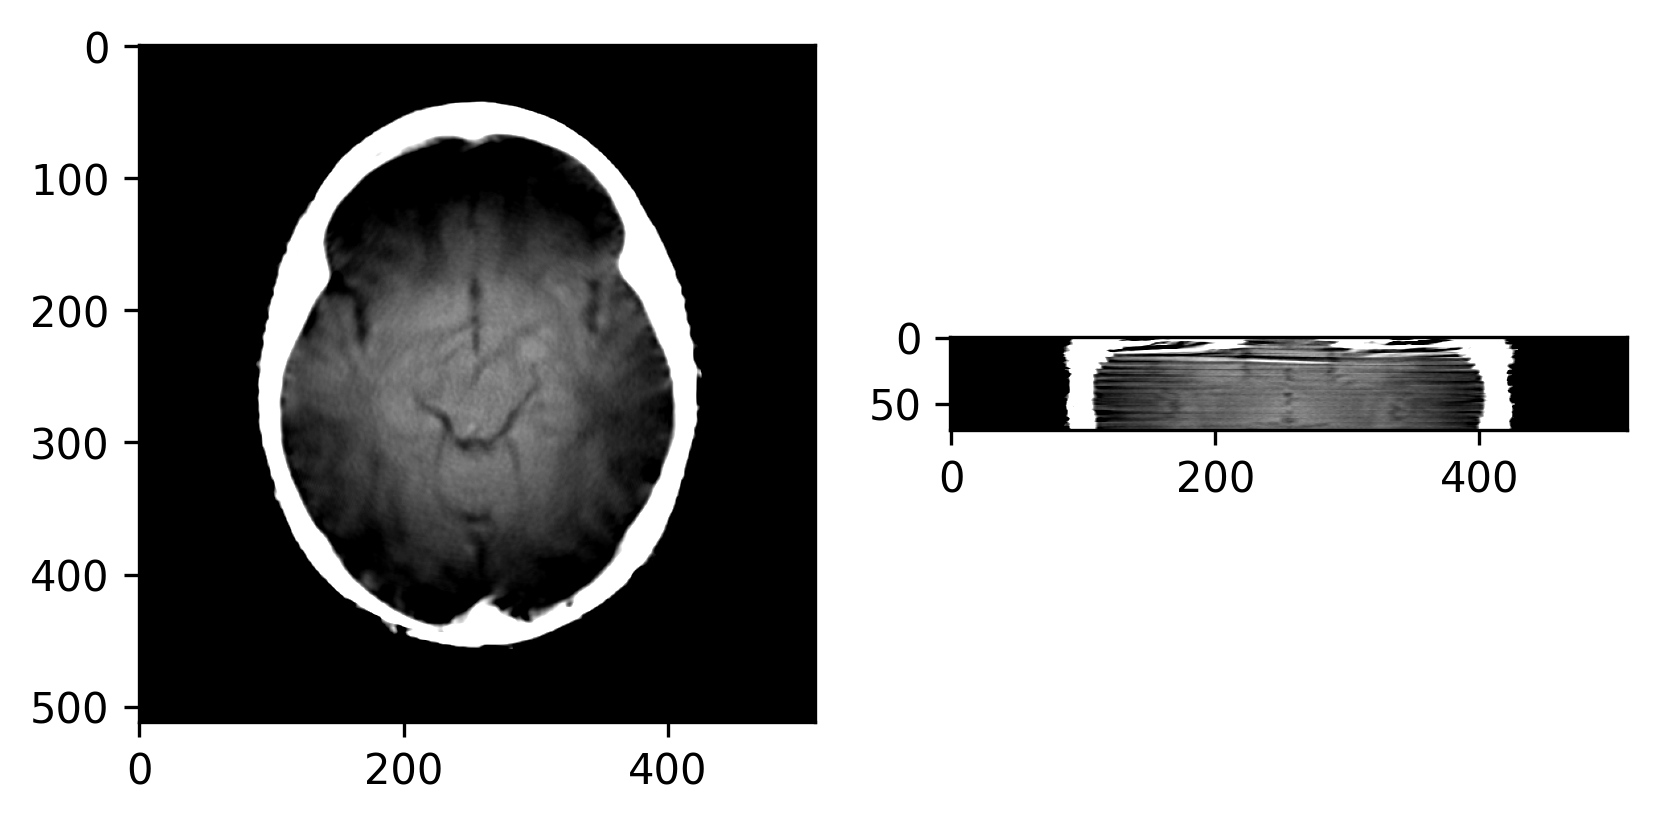

In [16]:
if ct.physics.monochromatic>0:
        ct.recon.mu = xc.GetMu('water', ct.physics.monochromatic)[0]/10

cfg = ct.get_current_cfg()

sliceThickness = 1
cfg.recon.sliceThickness = sliceThickness #0.568
sliceCount = int(desired_scan_length / cfg.recon.sliceThickness)
cfg.recon.sliceCount = sliceCount
print(f'slice thickness: {cfg.recon.sliceThickness}, sliceCount: {cfg.recon.sliceCount}')

cfg.do_Recon = 1
cfg.waitForKeypress = 0
cfg.recon.printReconParameters = False
vol = recon.recon_direct(cfg).transpose(2, 0, 1)

ww, wl = 80, 40
disp = dict(cmap='gray', vmin=wl-ww/2, vmax=wl+ww/2)
f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(vol[len(vol)//2], **disp)
axs[1].imshow(vol[:, 256], **disp)

In [ ]:
from utils import scrollview
scrollview(vol, 'brain')

interactive(children=(IntSlider(value=35, description='idx', max=69), Output()), _dom_classes=('widget-interac…

Below assigns table speed to set pitch

In [ ]:
import pandas as pd
import gecatsim as xc
from gecatsim.reconstruction.pyfiles import recon
import numpy as np

##--------- Initialize 
ct = xc.CatSim("../src/insilicoICH/defaults/helical_cfg/Phantom_Sample_Analytic",
               "../src/insilicoICH/defaults/helical_cfg/Protocol_Sample_Helical",
               "../src/insilicoICH/defaults/helical_cfg/Scanner_Sample_generic",
               "../src/insilicoICH/defaults/helical_cfg/Physics_Sample",
               "../src/insilicoICH/defaults/helical_cfg/Recon_Sample_Helical",
        )  # initialization

##--------- Make changes to parameters (optional)
# ct.phantom.filename = 'water20.ppm'
#ct.phantom.filename = 'CTDI_16cm_WaterAirPEBoneChambers.ppm'
ct.phantom.filename = scanner.xcist.cfg.phantom.filename
# rotations =
# scan_length = 50 # mm
desired_scan_length = 155 # mm
# pitch = 1


M = ct.cfg.scanner.sdd/ct.cfg.scanner.sid
sliceThickness = ct.cfg.scanner.detectorRowSize/M
nominal_aperature = sliceThickness*ct.cfg.scanner.detectorRowCount # nominal_aperature == s

ct.cfg.protocol.tableSpeed = 10 #18.189474

# table_travel_per_rotation = pitch*nominal_aperature # table_travel_per_rotation == d == v*t
table_travel_per_rotation = ct.cfg.protocol.tableSpeed*ct.cfg.protocol.rotationTime # table_travel_per_rotation == d == v*t
# h = vt/s = d/s
pitch = ct.cfg.protocol.tableSpeed*ct.cfg.protocol.rotationTime/nominal_aperature

rotations = np.ceil(desired_scan_length / table_travel_per_rotation).astype(int)
# rotations = desired_scan_length / table_travel_per_rotation
if rotations % 2 == 0:
        rotations += 1

ct.cfg.protocol.startZ = -75
ct.cfg.protocol.viewsPerRotation = views

# ct.cfg.protocol.viewCount = ct.cfg.protocol.viewsPerRotation*rotations
ct.cfg.protocol.viewCount = np.ceil(ct.cfg.protocol.viewsPerRotation*rotations).astype(int)

scan_time = rotations*ct.cfg.protocol.rotationTime

# ct.cfg.protocol.tableSpeed = required_speed #scan_length/(ct.cfg.protocol.rotationTime*ct.cfg.protocol.viewCount/ct.cfg.protocol.viewsPerRotation) # scan length/scan time
ct.cfg.protocol.stopViewId = ct.cfg.protocol.startViewId+ct.cfg.protocol.viewCount-1
ct.resultsName = "test_Helical"

##--------- Run simulation
df = pd.DataFrame({'pitch': [pitch], 'rotations': [rotations], 'scan length [mm]':[desired_scan_length], 'view count': [ct.cfg.protocol.viewCount], 'scan time [s]': [scan_time], 'tableSpeed [mm/s]': [ct.cfg.protocol.tableSpeed]})
df
ct.run_all()  # run the scans defined by protocol.scanTypes

Airscan
Offset scan
Phantom scan


  0%|          | 0/3100 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


  8%|▊         | 250/3100 [00:59<10:53,  4.36it/s]

100%|██████████| 3100/3100 [12:00<00:00,  4.30it/s]


Prep view
Applying LSC...done.

Simulation is done.


In [ ]:
df

,pitch,rotations,scan length [mm],view count,scan time [s],tableSpeed [mm/s]
0,0.549769,31,155,3100,15.5,10


slice thickness: 1, sliceCount: 155
* Loading the projection data...
* Rebinning the projection...
* Applying the filter...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/155...
   recon slice 1/155...
   recon slice 2/155...
   recon slice 3/155...
   recon slice 4/155...
   recon slice 5/155...
   recon slice 6/155...
   recon slice 7/155...
   recon slice 8/155...
   recon slice 9/155...
   recon slice 10/155...
   recon slice 11/155...
   recon slice 12/155...
   recon slice 13/155...
   recon slice 14/155...
   recon slice 15/155...
   recon slice 16/155...
   recon slice 17/155...
   recon slice 18/155...
   recon slice 19/155...
   recon slice 20/155...
   recon slice 21/155...
   recon slice 22/155...
   recon slice 23/155...
   recon slice 24/155...
   recon slice 25/155...
   recon slice 26/155...
   recon slice 27/155...
   recon slice 28/155...
   recon slice 29/155...
   recon slice

   recon slice 54/155...
   recon slice 55/155...
   recon slice 56/155...
   recon slice 57/155...
   recon slice 58/155...
   recon slice 59/155...
   recon slice 60/155...
   recon slice 61/155...
   recon slice 62/155...
   recon slice 63/155...
   recon slice 64/155...
   recon slice 65/155...
   recon slice 66/155...
   recon slice 67/155...
   recon slice 68/155...
   recon slice 69/155...
   recon slice 70/155...
   recon slice 71/155...
   recon slice 72/155...
   recon slice 73/155...
   recon slice 74/155...
   recon slice 75/155...
   recon slice 76/155...
   recon slice 77/155...
   recon slice 78/155...
   recon slice 79/155...
   recon slice 80/155...
   recon slice 81/155...
   recon slice 82/155...
   recon slice 83/155...
   recon slice 84/155...
   recon slice 85/155...
   recon slice 86/155...
   recon slice 87/155...
   recon slice 88/155...
   recon slice 89/155...
   recon slice 90/155...
   recon slice 91/155...
   recon slice 92/155...
   recon slice 93/155...


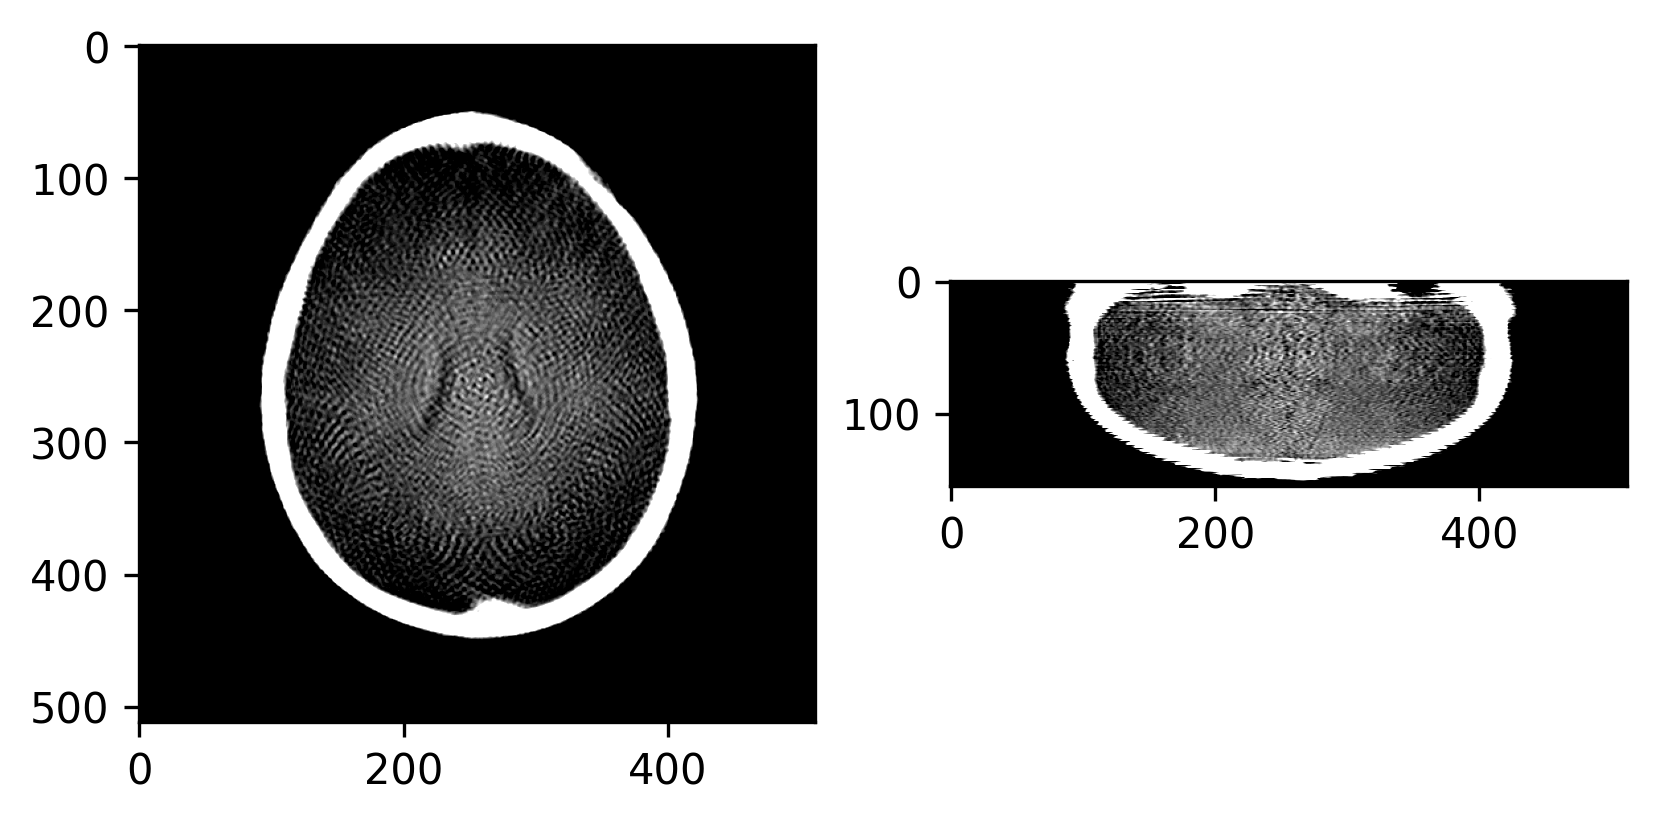

In [ ]:
if ct.physics.monochromatic>0:
        ct.recon.mu = xc.GetMu('water', ct.physics.monochromatic)[0]/10

cfg = ct.get_current_cfg()

sliceThickness = 1
cfg.recon.sliceThickness = sliceThickness #0.568
sliceCount = int(desired_scan_length / cfg.recon.sliceThickness)
cfg.recon.sliceCount = sliceCount
print(f'slice thickness: {cfg.recon.sliceThickness}, sliceCount: {cfg.recon.sliceCount}')

cfg.do_Recon = 1
cfg.waitForKeypress = 0
cfg.recon.printReconParameters = False
vol = recon.recon_direct(cfg).transpose(2, 0, 1)

ww, wl = 80, 40
disp = dict(cmap='gray', vmin=wl-ww/2, vmax=wl+ww/2)
f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(vol[len(vol)//2], **disp)
axs[1].imshow(vol[:, 256], **disp)

Check that the total number of views is what you'd expect based on the number of rotations and views per rotation:

For pitch = 1, axial and helical are similar, but by increasing the pitch the scan can be completed faster, or by reducing the pitch the dose can increase reducing noise

In [ ]:
%%time
acquisition_technique['pitch'] = 1.5

scanner.run_scan(**acquisition_technique)
scanner.run_recon(**recon_technique)

f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(scanner.recon[len(scanner.recon)//2], **disp)
axs[1].imshow(scanner.recon[:, 256], **disp)

Airscan
Offset scan
Phantom scan


  0%|          | 0/1300 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 1300/1300 [04:44<00:00,  4.56it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.


NameError: name 'recon_technique' is not defined

In [ ]:
%%time
acquisition_technique['pitch'] = 0.5

scanner.run_scan(**acquisition_technique)
scanner.run_recon(**recon_technique)

f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(scanner.recon[len(scanner.recon)//2], **disp)
axs[1].imshow(scanner.recon[:, 256], **disp)

Airscan
Offset scan
Phantom scan


  0%|          | 0/3500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 3500/3500 [12:43<00:00,  4.58it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.


NameError: name 'recon_technique' is not defined

In [ ]:
scanner.xcist.cfg.protocol.viewsPerRotation = 100
scanner.xcist.cfg.protocol.startZ = -75
endZ = 75
scanner.xcist.cfg.recon.sliceThickness = 1
scanner.xcist.cfg.protocol.rotationTime = 1
scanner.pitch = 1

# scanner.xcist.cfg.scanner.detectorRowCount = 64

# do not edit below
table_feed_per_rotation = scanner.pitch*scanner.scan_width

scanner.calculate_start_positions()
scanner.xcist.cfg.protocol.scanTrajectory = "Gantry_Helical"

scanner.xcist.cfg.protocol.spectrumFilename = "xcist_kVp120_tar7_bin1.dat"

exam_range = endZ - scanner.xcist.cfg.protocol.startZ
table_feed_per_rotation = scanner.scan_width * scanner.pitch # distance covered in mm in a 360 degree scan rotation
rotations = exam_range / table_feed_per_rotation
scanner.xcist.cfg.protocol.startViewId = -100
scanner.xcist.cfg.protocol.viewCount = np.ceil(scanner.xcist.cfg.protocol.viewsPerRotation*rotations).astype(int)
scanner.xcist.cfg.protocol.stopViewId = scanner.xcist.cfg.protocol.startViewId+scanner.xcist.cfg.protocol.viewCount-1

scan_duration = rotations * scanner.xcist.cfg.protocol.rotationTime
scanner.xcist.cfg.protocol.tableSpeed = exam_range / scan_duration

pd.DataFrame({'exam range [mm]': [exam_range], #  total scan coverage after all rotations
              'scan range [mm]': [scanner.scan_width], #  scan coverage after a single rotation
              'scan duration [s]': [scan_duration],
              'rotations': [rotations],
              'view count': [scanner.xcist.cfg.protocol.viewCount],
              'table speed [mm/s]': [scanner.xcist.cfg.protocol.tableSpeed]})

AttributeError: 'Scanner' object has no attribute 'scan_width'

In [ ]:
sliceCount = int(exam_range / scanner.xcist.cfg.recon.sliceThickness)
scanner.xcist.cfg.recon.reconType = 'helical_equiAngle'
scanner.xcist.cfg.recon.sliceCount = sliceCount
scanner

In [ ]:
scanner.xcist.run_all()

In [ ]:
from gecatsim.reconstruction.pyfiles import recon
vol = recon.recon_direct(scanner.xcist.cfg).transpose(2, 0, 1)
vol.shape

In [ ]:
f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(vol[len(vol)//2], **disp)
axs[1].imshow(vol[:, 256], **disp)

In [ ]:
scanner.xcist.cfg.protocol.tableSpeed

In [ ]:
scanner.xcist.cfg.protocol.wobbleDistance